# HAM10000 GAN + CLASSIFIER PIPELINE
## Improved for higher-quality and more diverse synthetic images
### Kaggle-ready single notebook code for skin cancer detection

In [7]:
# !cp -r "/kaggle/input/datasets/balu7989/kimtor/kaggle/working/checkpoints" /kaggle/working/

## Section 1: Environment Setup & Dependencies

In [8]:
!pip install -q kagglehub scikit-learn matplotlib seaborn pillow scipy tqdm

import kagglehub
import pandas as pd
import numpy as np
import os, shutil, glob, random, math, time, copy, warnings
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report
)
from scipy import linalg
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True
plt.style.use("seaborn-v0_8-darkgrid")

In [9]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

## Section 2: GPU Configuration & Device Setup

In [10]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("=" * 60)
print("CUDA & GPU Configuration")
print("=" * 60)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nDevice {i}: {props.name}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print(f"  Total Memory: {props.total_memory / 1e9:.1f} GB")
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True
    print(f"\n✓ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\n✗ CUDA not available. Using CPU.")

print(f"\n→ Using Device: {device}")
print("=" * 60)

CUDA & GPU Configuration
PyTorch Version: 2.10.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU Count: 2

Device 0: Tesla T4
  Compute Capability: 7.5
  Total Memory: 15.6 GB

Device 1: Tesla T4
  Compute Capability: 7.5
  Total Memory: 15.6 GB

✓ Using GPU: Tesla T4

→ Using Device: cuda


## Section 3: Download & Organize HAM10000 Dataset

In [11]:
# Download HAM10000
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)

meta_csv = None
for root_d, dirs, files in os.walk(path):
    for f in files:
        if f == "HAM10000_metadata.csv":
            meta_csv = os.path.join(root_d, f)
            break
    if meta_csv:
        break

assert meta_csv is not None, "HAM10000_metadata.csv not found!"
df = pd.read_csv(meta_csv)

print(f"Metadata loaded: {len(df)} rows")
print(df[["image_id", "dx"]].head())
print("Classes found:", sorted(df["dx"].unique()))

Dataset downloaded to: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Metadata loaded: 10015 rows
       image_id   dx
0  ISIC_0027419  bkl
1  ISIC_0025030  bkl
2  ISIC_0026769  bkl
3  ISIC_0025661  bkl
4  ISIC_0031633  bkl
Classes found: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [12]:
# Organize dataset
DATA_DIR = "/kaggle/working/data"
TRAIN_DIR = "/kaggle/working/train_original"
TEST_DIR = "/kaggle/working/test_original"
GEN_DIR = "/kaggle/working/train_generated"
AUG_DIR = "/kaggle/working/train_augmented"
CKPT_DIR = "/kaggle/working/checkpoints"
SAMPLE_DIR = "/kaggle/working/outputs/samples"

for d in [DATA_DIR, TRAIN_DIR, TEST_DIR, GEN_DIR, AUG_DIR, CKPT_DIR, SAMPLE_DIR]:
    os.makedirs(d, exist_ok=True)

image_dirs = []
for root_d, dirs, files in os.walk(path):
    for d in dirs:
        if "HAM10000_images" in d:
            image_dirs.append(os.path.join(root_d, d))
image_dirs.append(path)

all_images = {}
for img_dir in image_dirs:
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        for fp in glob.glob(os.path.join(img_dir, ext)):
            fname = os.path.splitext(os.path.basename(fp))[0]
            all_images[fname] = fp

classes = sorted(df["dx"].unique())
for cls in classes:
    os.makedirs(os.path.join(DATA_DIR, cls), exist_ok=True)

missing = 0
copied = 0
class_counts = {}

for _, row in tqdm(df.iterrows(), total=len(df), desc="Organizing images"):
    img_id = row["image_id"]
    cls = row["dx"]
    if img_id in all_images:
        src = all_images[img_id]
        dst = os.path.join(DATA_DIR, cls, os.path.basename(src))
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        copied += 1
        class_counts[cls] = class_counts.get(cls, 0) + 1
    else:
        missing += 1

print(f"Copied: {copied} | Missing: {missing}")
print("Class distribution:", class_counts)

all_paths, all_labels = [], []
for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_dir):
        all_paths.append(os.path.join(cls_dir, img_name))
        all_labels.append(cls)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels
)

def copy_split(paths, labels, dest_dir):
    counts = {}
    for p, l in zip(paths, labels):
        cls_dir = os.path.join(dest_dir, l)
        os.makedirs(cls_dir, exist_ok=True)
        dst = os.path.join(cls_dir, os.path.basename(p))
        if not os.path.exists(dst):
            shutil.copy2(p, dst)
        counts[l] = counts.get(l, 0) + 1
    return counts

train_counts = copy_split(train_paths, train_labels, TRAIN_DIR)
test_counts = copy_split(test_paths, test_labels, TEST_DIR)

print("\nTrain split:")
for c in sorted(train_counts):
    print(f"  {c}: {train_counts[c]}")
print("Test split:")
for c in sorted(test_counts):
    print(f"  {c}: {test_counts[c]}")

Organizing images:   0%|          | 0/10015 [00:00<?, ?it/s]

Copied: 10015 | Missing: 0
Class distribution: {'bkl': 1099, 'nv': 6705, 'df': 115, 'mel': 1113, 'vasc': 142, 'bcc': 514, 'akiec': 327}

Train split:
  akiec: 262
  bcc: 411
  bkl: 879
  df: 92
  mel: 890
  nv: 5364
  vasc: 114
Test split:
  akiec: 65
  bcc: 103
  bkl: 220
  df: 23
  mel: 223
  nv: 1341
  vasc: 28


## Section 4: Configuration & Data Transformations

In [13]:
# Configuration
IMG_SIZE = 128
CLF_IMG_SIZE = 128
BATCH_SIZE = 32
CLF_BATCH_SIZE = 64
Z_DIM = 256
STYLE_DIM = 256
GAN_EPOCHS = 380
CLF_EPOCHS = 30
NUM_WORKERS = 4 if torch.cuda.is_available() else 0
NUM_CLASSES = len(classes)

G_LR = 2e-4
D_LR = 2e-4
BETA1, BETA2 = 0.0, 0.99
R1_GAMMA = 5.0
R1_INTERVAL = 16
EMA_DECAY = 0.999
TOPK_START = 0.75
TOPK_END = 0.50
FID_EVERY = 20
SAMPLE_EVERY = 10
EARLY_STOP_PATIENCE = 5

# Transforms
gan_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08)
    ),
    transforms.ColorJitter(
        brightness=0.20, contrast=0.20, saturation=0.20, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

clf_transform_train = transforms.Compose([
    transforms.Resize((CLF_IMG_SIZE, CLF_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

clf_transform_test = transforms.Compose([
    transforms.Resize((CLF_IMG_SIZE, CLF_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## Section 5: Custom Dataset Class

In [14]:
class SkinDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.labels = []
        self.class_to_idx = {}
        classes_local = sorted([c for c in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, c))])

        for i, cls in enumerate(classes_local):
            self.class_to_idx[cls] = i
            cls_dir = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_dir):
                self.samples.append(os.path.join(cls_dir, img_name))
                self.labels.append(i)

        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = SkinDataset(TRAIN_DIR, transform=gan_transform)
labels = train_dataset.labels
class_count = Counter(labels)
class_weight = {cls: 1.0 / cnt for cls, cnt in class_count.items()}
sample_weights = [class_weight[label] for label in labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,   # ✅ FIX: avoid multiprocessing crash
    pin_memory=True,
    drop_last=True
)
print("GAN train dataset:", len(train_dataset))
print("GAN train batches:", len(train_loader))
print("Classes:", train_dataset.class_to_idx)

GAN train dataset: 8012
GAN train batches: 250
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


## Section 6: Adaptive Augmentation Strategy

In [15]:
class AdaptiveAugment:
    def __init__(self, p=0.0, target=0.6, speed=0.0002):
        self.p = p
        self.target = target
        self.speed = speed

    def update(self, logits_real):
        with torch.no_grad():
            signs = (logits_real > 0).float().mean().item()
            adjust = np.sign(signs - self.target) * self.speed
            self.p = float(np.clip(self.p + adjust, 0.0, 0.8))

    def __call__(self, x):
        if self.p <= 0:
            return x
        if random.random() < self.p:
            x = x + 0.05 * torch.randn_like(x)
        if random.random() < self.p:
            x = torch.roll(x, shifts=random.randint(-4, 4), dims=2)
        if random.random() < self.p:
            x = torch.roll(x, shifts=random.randint(-4, 4), dims=3)
        if random.random() < self.p:
            x = torch.clamp(x * (0.9 + 0.2 * torch.rand(x.size(0), 1, 1, 1, device=x.device)), -1, 1)
        return x

ada_aug = AdaptiveAugment()

## Section 7: GAN Architecture Components

In [16]:
class PixelNorm(nn.Module):
    def forward(self, x):
        return x / torch.sqrt(torch.mean(x ** 2, dim=1, keepdim=True) + 1e-8)

class MinibatchStdDev(nn.Module):
    def __init__(self, group_size=4):
        super().__init__()
        self.group_size = group_size

    def forward(self, x):
        B, C, H, W = x.shape
        G = min(self.group_size, B)
        if B % G != 0:
            G = 1
        y = x.view(G, -1, C, H, W)
        y = y - y.mean(dim=0, keepdim=True)
        y = torch.sqrt(y.pow(2).mean(dim=0) + 1e-8)
        y = y.mean(dim=[1, 2, 3], keepdim=True)
        y = y.repeat(G, 1, H, W)
        return torch.cat([x, y], dim=1)

class NoiseInjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        noise = torch.randn(x.size(0), 1, x.size(2), x.size(3), device=x.device)
        return x + self.weight * noise

class AdaIN(nn.Module):
    def __init__(self, channels, style_dim):
        super().__init__()
        self.norm = nn.InstanceNorm2d(channels)
        self.style = nn.Linear(style_dim, channels * 2)

    def forward(self, x, s):
        style = self.style(s).unsqueeze(-1).unsqueeze(-1)
        gamma, beta = style.chunk(2, dim=1)
        return gamma * self.norm(x) + beta

class StyleResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, style_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.noise1 = NoiseInjection()
        self.noise2 = NoiseInjection()
        self.adain1 = AdaIN(out_ch, style_dim)
        self.adain2 = AdaIN(out_ch, style_dim)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

        nn.init.kaiming_normal_(self.conv1.weight)
        nn.init.kaiming_normal_(self.conv2.weight)
        if isinstance(self.skip, nn.Conv2d):
            nn.init.kaiming_normal_(self.skip.weight)

    def forward(self, x, s):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        identity = self.skip(x)

        h = self.conv1(x)
        h = self.noise1(h)
        h = F.leaky_relu(self.adain1(h, s), 0.2)

        h = self.conv2(h)
        h = self.noise2(h)
        h = F.leaky_relu(self.adain2(h, s), 0.2)

        return F.leaky_relu(h + identity, 0.2)

## Section 8: StyleGenerator & Discriminator Models

In [17]:
class StyleGenerator(nn.Module):
    def __init__(self, z_dim=256, num_classes=7, style_dim=256, base_ch=64):
        super().__init__()
        self.z_dim = z_dim
        self.style_dim = style_dim
        self.class_embed = nn.Embedding(num_classes, style_dim)

        mapping = [PixelNorm()]
        for _ in range(4):
            mapping += [nn.Linear(style_dim, style_dim), nn.LeakyReLU(0.2, inplace=True)]
        self.mapping = nn.Sequential(*mapping)

        self.const = nn.Parameter(torch.randn(1, base_ch * 8, 4, 4))
        self.block1 = StyleResBlock(base_ch * 8, base_ch * 8, style_dim)  # 8
        self.block2 = StyleResBlock(base_ch * 8, base_ch * 4, style_dim)  # 16
        self.block3 = StyleResBlock(base_ch * 4, base_ch * 2, style_dim)  # 32
        self.block4 = StyleResBlock(base_ch * 2, base_ch, style_dim)      # 64
        self.block5 = StyleResBlock(base_ch, base_ch // 2, style_dim)     # 128

        self.to_rgb = nn.Sequential(
            nn.Conv2d(base_ch // 2, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, y):
        w = self.mapping(z)
        c = self.class_embed(y)
        s = (w + c) / 2.0

        h = self.const.repeat(z.size(0), 1, 1, 1)
        h = self.block1(h, s)
        h = self.block2(h, s)
        h = self.block3(h, s)
        h = self.block4(h, s)
        h = self.block5(h, s)
        return self.to_rgb(h)

class DiscResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()
        self.downsample = downsample
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, 1, 1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, 1, 1))
        self.skip = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 1))

        nn.init.orthogonal_(self.conv1.weight)
        nn.init.orthogonal_(self.conv2.weight)
        nn.init.orthogonal_(self.skip.weight)

    def forward(self, x):
        h = F.leaky_relu(self.conv1(x), 0.2)
        h = self.conv2(h)

        s = self.skip(x)

        if self.downsample:
            h = F.avg_pool2d(h, 2)
            s = F.avg_pool2d(s, 2)

        return h + s

class Discriminator(nn.Module):
    def __init__(self, num_classes=7, ch=64):
        super().__init__()
        self.block1 = DiscResBlock(3, ch)
        self.block2 = DiscResBlock(ch, ch * 2)
        self.block3 = DiscResBlock(ch * 2, ch * 4)
        self.block4 = DiscResBlock(ch * 4, ch * 8)
        self.stddev = MinibatchStdDev()
        self.final = nn.utils.spectral_norm(nn.Conv2d(ch * 8 + 1, ch * 8, 3, 1, 1))
        self.linear = nn.utils.spectral_norm(nn.Linear(ch * 8, 1))
        self.embed = nn.utils.spectral_norm(nn.Embedding(num_classes, ch * 8))

    def forward(self, x, y):
        h = self.block1(x)
        h = self.block2(h)
        h = self.block3(h)
        h = self.block4(h)
        h = self.stddev(h)
        h = F.leaky_relu(self.final(h), 0.2)
        h = h.sum(dim=[2, 3])

        out = self.linear(h)
        y_emb = self.embed(y)
        proj = (h * y_emb).sum(dim=1, keepdim=True)

        return out + proj

## Section 9: Build Models, Loss Functions & Utilities

In [18]:
# Build models
G = StyleGenerator(z_dim=Z_DIM, num_classes=NUM_CLASSES, style_dim=STYLE_DIM, base_ch=64).to(device)
D = Discriminator(num_classes=NUM_CLASSES, ch=64).to(device)
G_ema = copy.deepcopy(G).eval().to(device)

for p in G_ema.parameters():
    p.requires_grad = False

print(f"Generator params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

# Loss functions and helpers
def d_logistic_loss(real_pred, fake_pred):
    return F.softplus(-real_pred).mean() + F.softplus(fake_pred).mean()

def topk_percent_at_epoch(epoch, total_epochs, start=0.75, end=0.50):
    alpha = min(1.0, epoch / total_epochs)
    return start + (end - start) * alpha

def g_topk_loss(fake_pred, current_topk=0.5):
    k = max(1, int(fake_pred.size(0) * current_topk))
    topk_vals, _ = torch.topk(fake_pred.view(-1), k=k)
    return F.softplus(-topk_vals).mean()

@torch.no_grad()
def update_ema(model, ema_model, decay=0.999):
    msd = model.state_dict()
    esd = ema_model.state_dict()
    for k in esd.keys():
        esd[k].copy_(esd[k] * decay + msd[k] * (1.0 - decay))

def requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

Generator params: 8,539,021
Discriminator params: 7,227,073


## Section 10: Checkpoint Management

In [19]:
def save_checkpoint(epoch, best_fid, no_improve_epochs):
    torch.save({
        "epoch": epoch,
        "best_fid": best_fid,
        "no_improve_epochs": no_improve_epochs,
        "G": G.state_dict(),
        "D": D.state_dict(),
        "G_ema": G_ema.state_dict(),
        "g_opt": g_opt.state_dict(),
        "d_opt": d_opt.state_dict(),
        "ada_p": ada_aug.p
    }, os.path.join(CKPT_DIR, "checkpoint.pt"))

def load_checkpoint():
    ckpt_path = os.path.join(CKPT_DIR, "checkpoint.pt")
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        G.load_state_dict(ckpt["G"])
        D.load_state_dict(ckpt["D"])
        G_ema.load_state_dict(ckpt["G_ema"])
        g_opt.load_state_dict(ckpt["g_opt"])
        d_opt.load_state_dict(ckpt["d_opt"])
        ada_aug.p = ckpt.get("ada_p", 0.0)
        print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
        return ckpt["epoch"], ckpt["best_fid"], ckpt.get("no_improve_epochs", 0)
    return 0, float("inf"), 0

## Section 11: FID Score Calculator

In [20]:
class FIDCalculator:
    def __init__(self, device):
        self.device = device
        self.inception = models.inception_v3(
            weights=models.Inception_V3_Weights.DEFAULT,
            transform_input=False
        ).to(device)
        self.inception.fc = nn.Identity()
        self.inception.eval()
        self.resize = transforms.Resize((299, 299), antialias=True)

        for p in self.inception.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def get_features(self, images):
        imgs = self.resize(images)
        if imgs.min() < 0:
            imgs = (imgs + 1) / 2
        feats = self.inception(imgs)
        return feats.cpu().numpy()

    def compute_fid(self, real_loader, generator, z_dim, num_classes, n_samples=1000):
        real_feats, fake_feats = [], []

        count = 0
        for imgs, _ in real_loader:
            if count >= n_samples:
                break
            imgs = imgs.to(self.device)
            feats = self.get_features(imgs)
            real_feats.append(feats)
            count += len(imgs)
        real_feats = np.concatenate(real_feats, axis=0)[:n_samples]

        generator.eval()
        count = 0
        while count < n_samples:
            bs = min(32, n_samples - count)
            z = torch.randn(bs, z_dim, device=self.device)
            y = torch.randint(0, num_classes, (bs,), device=self.device)
            fake = generator(z, y)
            feats = self.get_features(fake)
            fake_feats.append(feats)
            count += bs
        fake_feats = np.concatenate(fake_feats, axis=0)[:n_samples]

        mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
        mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
        diff = mu1 - mu2
        covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
        return float(fid)

fid_calc = FIDCalculator(device)

## Section 12: Optimizers Setup & Training Initialization

In [21]:
g_opt = optim.Adam(G.parameters(), lr=G_LR, betas=(BETA1, BETA2))
d_opt = optim.Adam(D.parameters(), lr=D_LR, betas=(BETA1, BETA2))

start_epoch, best_fid, no_improve_epochs = load_checkpoint()

fixed_noise = torch.randn(32, Z_DIM, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device).repeat(10)[:32]

g_losses, d_losses, fid_scores = [], [], []

print(f"Initializing optimizers and training state...")
print(f"Starting from epoch: {start_epoch + 1}")

Loaded checkpoint from epoch 310
Initializing optimizers and training state...
Starting from epoch: 311


In [22]:
fid_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,   # ✅ MUST be 0
    pin_memory=True
)

## Section 13: GAN Training Loop

In [23]:
print(f"\nStarting GAN training: epochs {start_epoch + 1} → {GAN_EPOCHS}")

for epoch in range(start_epoch + 1, GAN_EPOCHS + 1):
    G.train()
    D.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    g_steps, d_steps = 0, 0

    current_topk = topk_percent_at_epoch(epoch, GAN_EPOCHS, TOPK_START, TOPK_END)

    pbar = tqdm(train_loader, desc=f"GAN Epoch {epoch}/{GAN_EPOCHS}")
    for step, (real_imgs, real_labels) in enumerate(pbar):
        real_imgs = real_imgs.to(device, non_blocking=True)
        real_labels = real_labels.to(device, dtype=torch.long, non_blocking=True)
        bs = real_imgs.size(0)

        # Train D
        requires_grad(D, True)
        requires_grad(G, False)

        z = torch.randn(bs, Z_DIM, device=device)
        fake_labels = torch.randint(0, NUM_CLASSES, (bs,), device=device)

        with torch.no_grad():
            fake_imgs = G(z, fake_labels)

        real_aug = ada_aug(real_imgs)
        fake_aug = ada_aug(fake_imgs)

        real_pred = D(real_aug, real_labels)
        fake_pred = D(fake_aug, fake_labels)

        d_loss = d_logistic_loss(real_pred, fake_pred)

        if step % R1_INTERVAL == 0:
            real_imgs.requires_grad_(True)
            real_pred_r1 = D(real_imgs, real_labels)
            grad_real = torch.autograd.grad(
                outputs=real_pred_r1.sum(),
                inputs=real_imgs,
                create_graph=True
            )[0]
            r1_penalty = grad_real.pow(2).reshape(bs, -1).sum(1).mean()
            d_loss = d_loss + (R1_GAMMA * 0.5 * R1_INTERVAL) * r1_penalty

        d_opt.zero_grad(set_to_none=True)
        with autocast():
            real_pred = D(real_aug, real_labels)
            fake_pred = D(fake_aug, fake_labels)
            d_loss = d_logistic_loss(real_pred, fake_pred)
        
        scaler.scale(d_loss).backward()
        scaler.step(d_opt)
        scaler.update()
        epoch_d_loss += d_loss.item()
        d_steps += 1

        ada_aug.update(real_pred.detach())

        # Train G
        requires_grad(D, False)
        requires_grad(G, True)

        z = torch.randn(bs, Z_DIM, device=device)
        gen_labels = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        fake_imgs = G(z, gen_labels)
        fake_aug = ada_aug(fake_imgs)
        fake_pred = D(fake_aug, gen_labels)

        g_loss = g_topk_loss(fake_pred, current_topk=current_topk)

        g_opt.zero_grad(set_to_none=True)
        with autocast():
            fake_imgs = G(z, gen_labels)
            fake_aug = ada_aug(fake_imgs)
            fake_pred = D(fake_aug, gen_labels)
            g_loss = g_topk_loss(fake_pred, current_topk=current_topk)
        
        scaler.scale(g_loss).backward()
        scaler.step(g_opt)
        scaler.update()

        update_ema(G, G_ema, EMA_DECAY)

        epoch_g_loss += g_loss.item()
        g_steps += 1

        pbar.set_postfix({
            "D": f"{epoch_d_loss/max(d_steps,1):.3f}",
            "G": f"{epoch_g_loss/max(g_steps,1):.3f}",
            "ADA_p": f"{ada_aug.p:.3f}",
            "topk": f"{current_topk:.2f}"
        })

    avg_g = epoch_g_loss / max(g_steps, 1)
    avg_d = epoch_d_loss / max(d_steps, 1)
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    print(f"Epoch {epoch}/{GAN_EPOCHS} | G_loss={avg_g:.4f} | D_loss={avg_d:.4f} | ADA p={ada_aug.p:.3f}")

    if epoch % SAMPLE_EVERY == 0:
        G_ema.eval()
        with torch.no_grad():
            fake_images = G_ema(fixed_noise, fixed_labels)
        save_image(
            fake_images,
            os.path.join(SAMPLE_DIR, f"samples_epoch_{epoch}.png"),
            nrow=8,
            normalize=True,
            value_range=(-1, 1)
        )

    if epoch % FID_EVERY == 0:
        print("Computing FID...")
        fid = fid_calc.compute_fid(fid_loader, G_ema, Z_DIM, NUM_CLASSES, n_samples=700)
        fid_scores.append((epoch, fid))
        print(f"FID: {fid:.2f} | Best: {best_fid:.2f}")

        if fid < best_fid:
            best_fid = fid
            no_improve_epochs = 0
            torch.save({
                "G_ema": G_ema.state_dict(),
                "fid": best_fid
            }, os.path.join(CKPT_DIR, "best_generator.pt"))
            print(f"[Best Generator Saved] FID={best_fid:.2f}")
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= EARLY_STOP_PATIENCE:
            print("Early stopping triggered due to FID plateau.")
            save_checkpoint(epoch, best_fid, no_improve_epochs)
            break

    if epoch % 10 == 0:
        save_checkpoint(epoch, best_fid, no_improve_epochs)

print("\nGAN training complete.")
print(f"Best FID: {best_fid:.2f}")


Starting GAN training: epochs 311 → 380


GAN Epoch 311/380:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 311/380 | G_loss=0.7834 | D_loss=1.0812 | ADA p=0.800


GAN Epoch 312/380:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 312/380 | G_loss=0.7715 | D_loss=1.0648 | ADA p=0.800


...

Epoch 370/380 | G_loss=0.7782 | D_loss=0.9760 | ADA p=0.800


GAN Epoch 371/380:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 371/380 | G_loss=0.7742 | D_loss=0.9420 | ADA p=0.800


GAN Epoch 372/380:   0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [24]:
!zip -r checkpoints2.zip /kaggle/working/checkpoints

  adding: kaggle/working/checkpoints/ (stored 0%)
  adding: kaggle/working/checkpoints/checkpoint.pt (deflated 13%)
  adding: kaggle/working/checkpoints/best_generator.pt (deflated 7%)


## Section 14: GAN Training Visualization

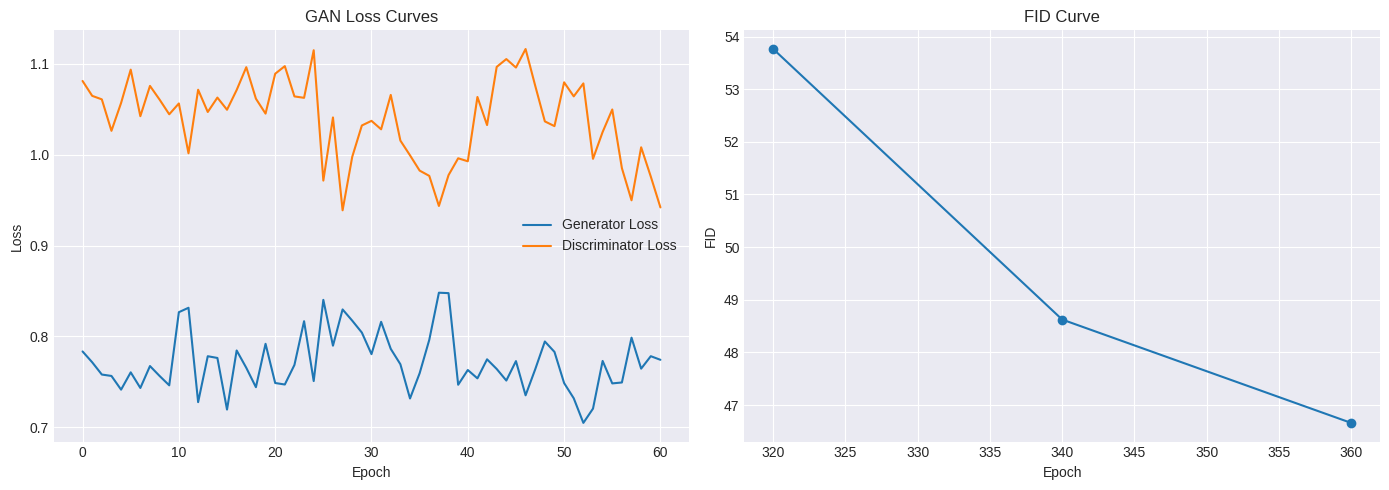

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(g_losses, label="Generator Loss")
ax[0].plot(d_losses, label="Discriminator Loss")
ax[0].set_title("GAN Loss Curves")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

if len(fid_scores) > 0:
    ax[1].plot([x[0] for x in fid_scores], [x[1] for x in fid_scores], marker="o")
    ax[1].set_title("FID Curve")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("FID")
plt.tight_layout()
plt.show()

## Section 15: Load Best Generator & Smart Oversampling

In [26]:
best_gen_path = os.path.join(CKPT_DIR, "best_generator.pt")
if os.path.exists(best_gen_path):
    ckpt = torch.load(best_gen_path, map_location=device)
    G_ema.load_state_dict(ckpt["G_ema"])
    print(f"Loaded best EMA generator (FID={ckpt['fid']:.2f})")
else:
    print("Best generator not found. Using current EMA generator.")

G_ema.eval()
idx_to_class = train_dataset.idx_to_class
class_to_idx = train_dataset.class_to_idx

# Smart minority oversampling
original_counts = {}
for cls in classes:
    original_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))

max_count = max(original_counts.values())
print("\nOriginal training counts:")
print(original_counts)
print("Majority class size:", max_count)

def smart_oversample(counts, target_ratio=0.90, max_multiplier=3.0):
    generation_plan = {}
    max_count = max(counts.values())
    target_count = int(max_count * target_ratio)

    for cls, count in counts.items():
        if count >= target_count:
            generation_plan[cls] = 0
        else:
            needed = target_count - count
            cap = int(count * (max_multiplier - 1.0))
            generation_plan[cls] = max(0, min(needed, cap))
    return generation_plan

generation_plan = smart_oversample(original_counts, target_ratio=0.90, max_multiplier=3.0)

print("\nSynthetic generation plan:")
for cls in classes:
    print(f"  {cls}: original={original_counts[cls]} | generate={generation_plan[cls]} | total={original_counts[cls] + generation_plan[cls]}")

Loaded best EMA generator (FID=46.66)

Original training counts:
{'akiec': 262, 'bcc': 411, 'bkl': 879, 'df': 92, 'mel': 890, 'nv': 5364, 'vasc': 114}
Majority class size: 5364

Synthetic generation plan:
  akiec: original=262 | generate=524 | total=786
  bcc: original=411 | generate=822 | total=1233
  bkl: original=879 | generate=1758 | total=2637
  df: original=92 | generate=184 | total=276
  mel: original=890 | generate=1780 | total=2670
  nv: original=5364 | generate=0 | total=5364
  vasc: original=114 | generate=228 | total=342


## Section 16: Generate Synthetic Images

In [27]:
with torch.no_grad():
    for cls_name, n_to_generate in generation_plan.items():
        if n_to_generate <= 0:
            continue

        cls_idx = class_to_idx[cls_name]
        gen_cls_dir = os.path.join(GEN_DIR, cls_name)
        os.makedirs(gen_cls_dir, exist_ok=True)

        generated = 0
        pbar = tqdm(total=n_to_generate, desc=f"Generating {cls_name}")

        while generated < n_to_generate:
            bs = min(32, n_to_generate - generated)
            z = torch.randn(bs, Z_DIM, device=device)
            y = torch.full((bs,), cls_idx, dtype=torch.long, device=device)

            fake_imgs = G_ema(z, y)
            fake_imgs = (fake_imgs + 1) / 2.0
            fake_imgs = torch.clamp(fake_imgs, 0, 1)

            for i in range(bs):
                img = transforms.ToPILImage()(fake_imgs[i].cpu())
                img.save(os.path.join(gen_cls_dir, f"syn_{cls_name}_{generated+i:05d}.jpg"), quality=95)

            generated += bs
            pbar.update(bs)

        pbar.close()

print("\nGeneration complete.")
for cls in classes:
    gen_dir = os.path.join(GEN_DIR, cls)
    n_gen = len(os.listdir(gen_dir)) if os.path.exists(gen_dir) else 0
    print(f"{cls}: {original_counts[cls]} original + {n_gen} synthetic = {original_counts[cls] + n_gen}")

Generating akiec:   0%|          | 0/524 [00:00<?, ?it/s]

Generating bcc:   0%|          | 0/822 [00:00<?, ?it/s]

Generating bkl:   0%|          | 0/1758 [00:00<?, ?it/s]

Generating df:   0%|          | 0/184 [00:00<?, ?it/s]

Generating mel:   0%|          | 0/1780 [00:00<?, ?it/s]

Generating vasc:   0%|          | 0/228 [00:00<?, ?it/s]


Generation complete.
akiec: 262 original + 524 synthetic = 786
bcc: 411 original + 822 synthetic = 1233
bkl: 879 original + 1758 synthetic = 2637
df: 92 original + 184 synthetic = 276
mel: 890 original + 1780 synthetic = 2670
nv: 5364 original + 0 synthetic = 5364
vasc: 114 original + 228 synthetic = 342


## Section 17: Merge Original & Synthetic Datasets

In [28]:
for cls in classes:
    aug_cls_dir = os.path.join(AUG_DIR, cls)
    os.makedirs(aug_cls_dir, exist_ok=True)

    # originals
    orig_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(orig_dir):
        src = os.path.join(orig_dir, fname)
        dst = os.path.join(aug_cls_dir, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    # synthetics
    gen_dir = os.path.join(GEN_DIR, cls)
    if os.path.exists(gen_dir):
        for fname in os.listdir(gen_dir):
            src = os.path.join(gen_dir, fname)
            dst = os.path.join(aug_cls_dir, fname)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)

print("\nAugmented dataset counts:")
total_aug = 0
for cls in classes:
    n = len(os.listdir(os.path.join(AUG_DIR, cls)))
    total_aug += n
    print(f"  {cls}: {n}")
print("  Total:", total_aug)


Augmented dataset counts:
  akiec: 786
  bcc: 1233
  bkl: 2637
  df: 276
  mel: 2670
  nv: 5364
  vasc: 342
  Total: 13308


## Section 18: Classifier Datasets & DataLoaders

In [29]:
aug_dataset = SkinDataset(AUG_DIR, transform=clf_transform_train)
test_dataset = SkinDataset(TEST_DIR, transform=clf_transform_test)

aug_loader = DataLoader(
    aug_dataset,
    batch_size=CLF_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CLF_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print(f"\nAugmented train set: {len(aug_dataset)}")
print(f"Test set: {len(test_dataset)}")


Augmented train set: 13308
Test set: 2003


## Section 19: ResNet-18 Classifier Training

In [30]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(device)

clf_optimizer = optim.AdamW(resnet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(clf_optimizer, T_max=CLF_EPOCHS)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
train_losses = []
val_accs = []

print(f"\nTraining ResNet-18 for {CLF_EPOCHS} epochs...")

for epoch in range(1, CLF_EPOCHS + 1):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(aug_loader, desc=f"Clf Epoch {epoch}/{CLF_EPOCHS}")
    for imgs, labels in pbar:
        imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
        labels = labels.to(device, dtype=torch.long, non_blocking=True)

        out = resnet(imgs)
        loss = criterion(out, labels)

        clf_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        clf_optimizer.step()

        running_loss += loss.item()
        preds = out.argmax(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "acc": f"{100.0 * correct / total:.1f}%"
        })

    scheduler.step()
    train_loss = running_loss / len(aug_loader)
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)

    resnet.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            labels = labels.to(device, dtype=torch.long, non_blocking=True)

            out = resnet(imgs)
            preds = out.argmax(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100.0 * val_correct / val_total
    val_accs.append(val_acc)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet.state_dict(), "/kaggle/working/best_resnet18.pt")
        print(f"[Best classifier saved] Val Acc: {best_val_acc:.2f}%")

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s] 



Training ResNet-18 for 30 epochs...


Clf Epoch 1/30:   0%|          | 0/208 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.7911 | Train Acc: 70.74% | Val Acc: 77.03%
[Best classifier saved] Val Acc: 77.03%


...

Clf Epoch 29/30:   0%|          | 0/208 [00:00<?, ?it/s]

Epoch 29 | Train Loss: 0.0636 | Train Acc: 97.96% | Val Acc: 85.77%


Clf Epoch 30/30:   0%|          | 0/208 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c7f77aa34c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7c7f77aa34c0>
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    if w.is_alive():^^
^^ ^ ^ ^^ ^ ^ ^ ^^^^^^^^

Epoch 30 | Train Loss: 0.0644 | Train Acc: 97.91% | Val Acc: 85.87%

Best validation accuracy: 86.57%


## Section 20: Classifier Performance Visualization

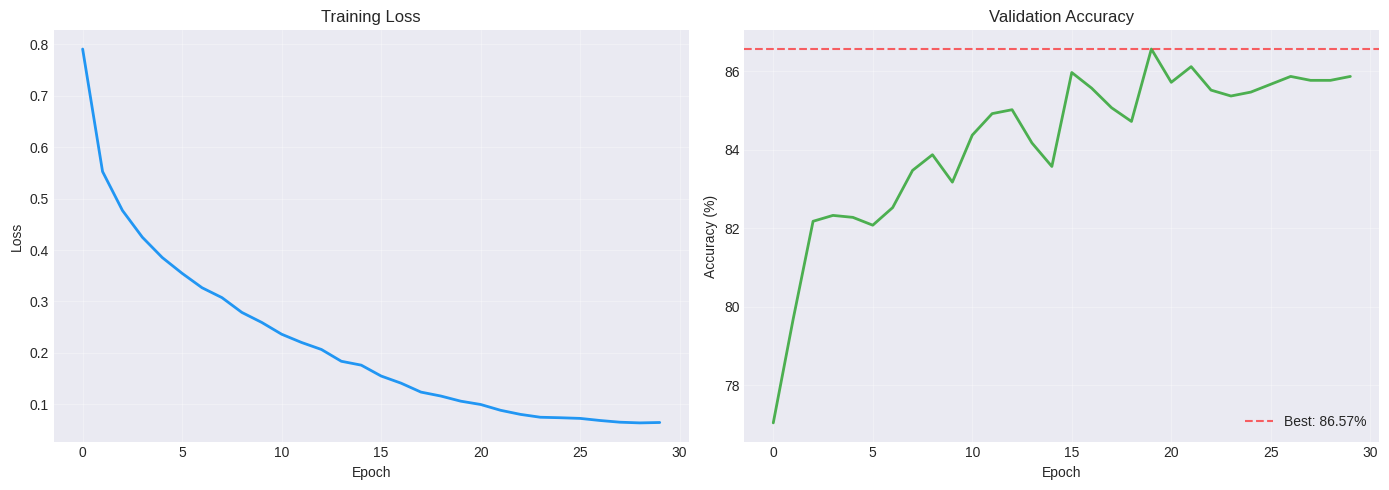

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, color="#2196F3", linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, color="#4CAF50", linewidth=2)
ax2.axhline(y=best_val_acc, color="red", linestyle="--", alpha=0.6, label=f"Best: {best_val_acc:.2f}%")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 21: Final Evaluation & Metrics

In [32]:
resnet.load_state_dict(torch.load("/kaggle/working/best_resnet18.pt", map_location=device))
resnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(device, dtype=torch.float32)
        out = resnet(imgs)
        probs = F.softmax(out, dim=1)
        preds = out.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

class_names = [test_dataset.idx_to_class[i] for i in range(NUM_CLASSES)]

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="weighted")
rec = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

try:
    roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted")
except:
    roc_auc = float("nan")

print("=" * 60)
print("FINAL EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy :  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision:  {prec:.4f}")
print(f"Recall   :  {rec:.4f}")
print(f"F1 Score :  {f1:.4f}")
print(f"ROC-AUC  :  {roc_auc:.4f}")
print("=" * 60)
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

FINAL EVALUATION RESULTS
Accuracy :  0.8657 (86.57%)
Precision:  0.8603
Recall   :  0.8657
F1 Score :  0.8617
ROC-AUC  :  0.9628

              precision    recall  f1-score   support

       akiec       0.59      0.57      0.58        65
         bcc       0.75      0.83      0.79       103
         bkl       0.74      0.65      0.69       220
          df       0.88      0.61      0.72        23
         mel       0.71      0.61      0.66       223
          nv       0.92      0.96      0.94      1341
        vasc       0.96      0.93      0.95        28

    accuracy                           0.87      2003
   macro avg       0.79      0.74      0.76      2003
weighted avg       0.86      0.87      0.86      2003



## Section 22: Confusion Matrix & Per-Class Analysis

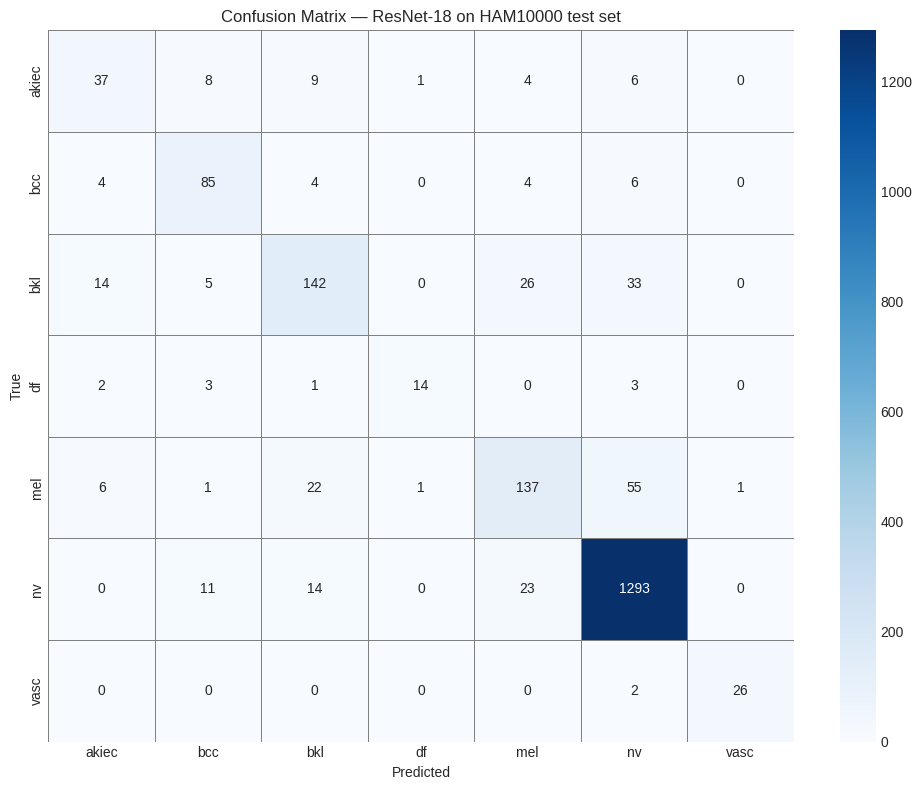

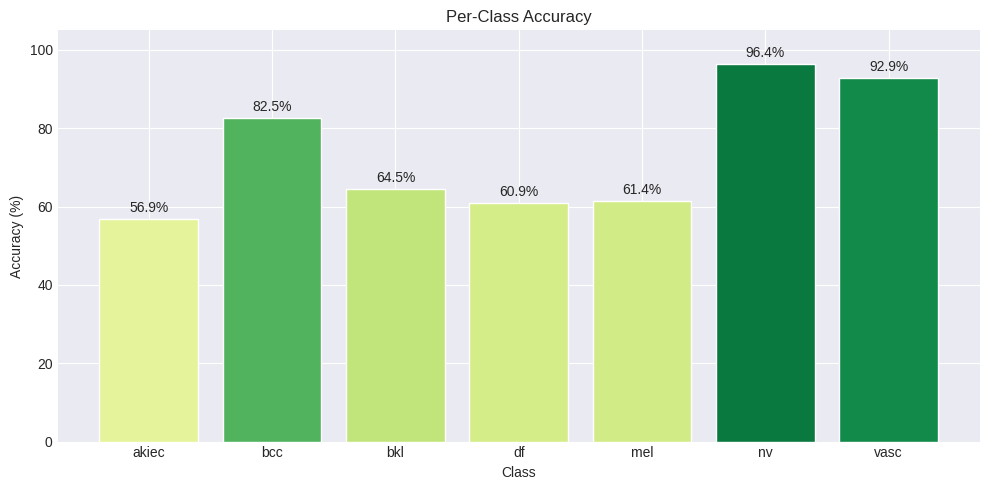


✅ Pipeline complete!
Best GAN FID: 46.66
Best classifier validation accuracy: 86.57%


In [33]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor="gray", ax=ax
)
ax.set_title("Confusion Matrix — ResNet-18 on HAM10000 test set")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_acc * 100, color=plt.cm.RdYlGn(per_class_acc), edgecolor="white")
for bar, val in zip(bars, per_class_acc * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%", ha="center", va="bottom")
ax.set_title("Per-Class Accuracy")
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print("\n✅ Pipeline complete!")
print(f"Best GAN FID: {best_fid:.2f}")
print(f"Best classifier validation accuracy: {best_val_acc:.2f}%")

In [34]:
import os
import random
import shutil

SOURCE_DIR = "/kaggle/working/train_generated"
DEST_DIR = "/kaggle/working/sample_30_per_class"

os.makedirs(DEST_DIR, exist_ok=True)

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        selected = random.sample(images, min(30, len(images)))
        
        dest_class_path = os.path.join(DEST_DIR, class_name)
        os.makedirs(dest_class_path, exist_ok=True)
        
        for img in selected:
            src = os.path.join(class_path, img)
            dst = os.path.join(dest_class_path, img)
            shutil.copy(src, dst)

print("✅ 30 samples per class copied!")

✅ 30 samples per class copied!


In [35]:
!zip -r sample_30_per_class.zip /kaggle/working/sample_30_per_class

  adding: kaggle/working/sample_30_per_class/ (stored 0%)
  adding: kaggle/working/sample_30_per_class/mel/ (stored 0%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_01116.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00739.jpg (deflated 2%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_01503.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00683.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00551.jpg (deflated 2%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00651.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00139.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00576.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00689.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_00653.jpg (deflated 3%)
  adding: kaggle/working/sample_30_per_class/mel/syn_mel_01440.jpg (de

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

# ===== CONFIG =====
DATA_SOURCE = AUG_DIR   # you can change to TRAIN_DIR / GEN_DIR if needed
NUM_IMAGES_PER_CLASS = 10
NUM_GRIDS = 3
SAVE_DIR = "/kaggle/working/outputs/grids"
os.makedirs(SAVE_DIR, exist_ok=True)

classes = sorted(os.listdir(DATA_SOURCE))

def create_grid(grid_id):
    fig, axes = plt.subplots(len(classes), NUM_IMAGES_PER_CLASS, figsize=(15, 2 * len(classes)))
    
    for row, cls in enumerate(classes):
        cls_path = os.path.join(DATA_SOURCE, cls)
        images = os.listdir(cls_path)
        
        # Randomly pick 10 images
        selected_imgs = random.sample(images, min(NUM_IMAGES_PER_CLASS, len(images)))
        
        for col in range(NUM_IMAGES_PER_CLASS):
            ax = axes[row, col] if len(classes) > 1 else axes[col]
            
            if col < len(selected_imgs):
                img_path = os.path.join(cls_path, selected_imgs[col])
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            else:
                ax.imshow([[0]])  # empty
            
            ax.axis("off")
            
            # Add class label on first column
            if col == 0:
                ax.set_title(cls, fontsize=10, loc='left')
    
    plt.tight_layout()
    
    save_path = os.path.join(SAVE_DIR, f"grid_{grid_id}.png")
    plt.savefig(save_path)
    plt.close()
    
    print(f"✅ Grid {grid_id} saved at:", save_path)


# ===== GENERATE 3 GRIDS =====
for i in range(1, NUM_GRIDS + 1):
    create_grid(i)

✅ Grid 1 saved at: /kaggle/working/outputs/grids/grid_1.png
✅ Grid 2 saved at: /kaggle/working/outputs/grids/grid_2.png
